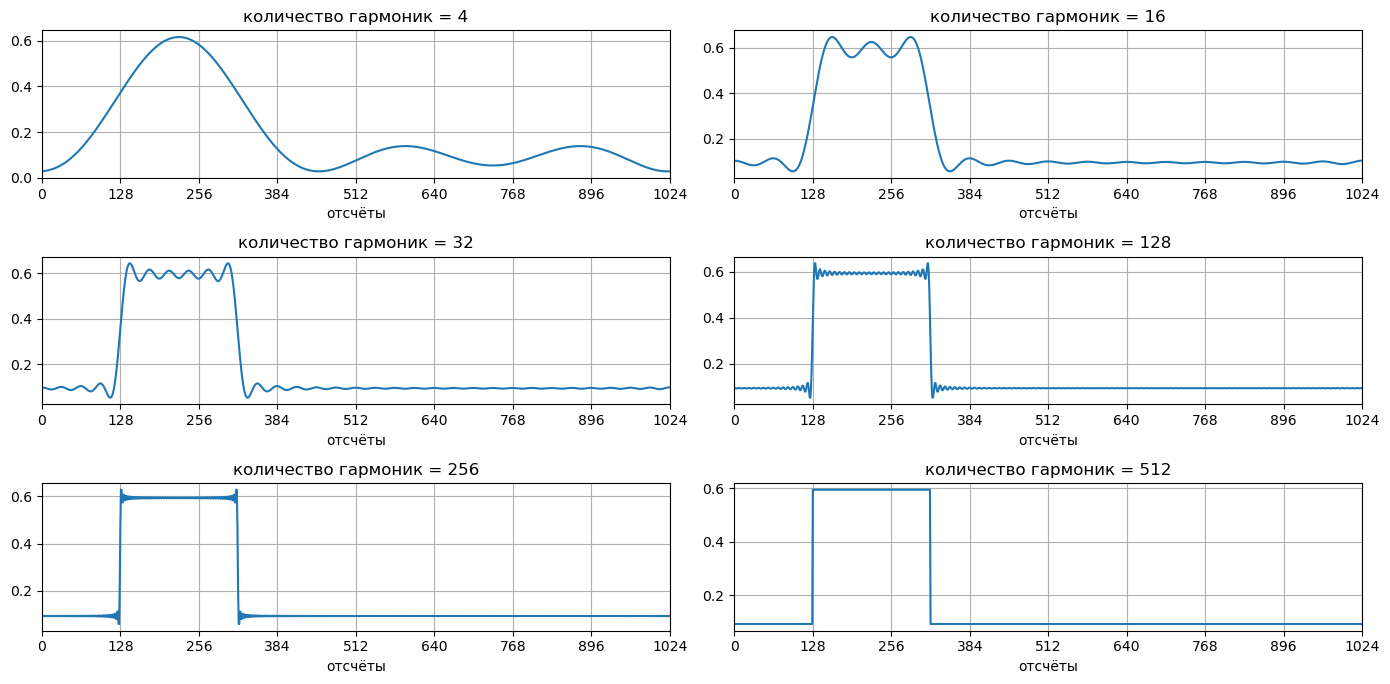

In [9]:
# вывод графиком восстановленного сигнала

# импортируем необходимые библиотеки
import numpy as np
import matplotlib.pyplot as plt

# команда для отображения графиков прямо внутри ноутбука
%matplotlib inline


# задаем размер сигнала
N = 1024
# создаем исходный прямоугольный сигнал
x = np.zeros(N)
x[128:320] = 1  # устанавливаем интервал с значением 1

# находим бпф исходного сигнала
X = np.fft.fft(x, N)
# сдвигаем нулевую частоту в центр спектра и берем модуль (амплитуду)
Xs = np.fft.fftshift(np.abs(X))
# создаем массив нормализованных частот от -0.5 до 0.5
f = np.linspace(-0.5, 0.5, N, endpoint=True)

# задаем список с количествами гармоник для восстановления сигнала
harmonics = (4, 16, 32, 128, 256, N//2)
# создаем фигуру для отображения с заданными размерами и разрешением
plt.figure(figsize=(14, 9), dpi=100)
# цикл по индексам и значениям в списке гармоник
for i, j in enumerate(harmonics):
    # создаем подграфик в сетке 4x2, начиная с третьего места (i+3)
    plt.subplot(4, 2, i+3)
    # копируем массив X (частотный спектр), чтобы не изменять оригинал
    K = X.copy()
    # обнуляем все компоненты спектра с индексами, начиная с j
    K[j:] = 0
    # выполняем обратное преобразование Фурье и берем только действительные части
    k = np.real(np.fft.ifft(K))
    # строим восстановленный сигнал
    plt.plot(k)
    # задаем заголовок с количеством гармоник
    plt.title(f'количество гармоник = {j}')
    # задаем подпись оси x
    plt.xlabel('отсчёты')
    # ограничиваем ось по количеству отсчетов
    plt.xlim([0, N-1])
    # задаем метки по оси x с равными интервалами
    plt.xticks(np.linspace(0, N, 9, endpoint=True))
    # включаем сетку
    plt.grid()
plt.tight_layout()